<a href="https://colab.research.google.com/github/kny1209/test2/blob/main/AI/%EA%B0%95%EC%9D%98_8%EA%B8%B0_AI%EA%B0%9C%EB%A1%A0_9%EC%B0%A8%EC%8B%9C_02_%EB%8B%A4%EC%B8%B5%EC%8B%A0%EA%B2%BD%EB%A7%9D_%EB%8B%A4%EC%A4%91%EB%B6%84%EB%A5%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 심화 실습 1: 다층 신경망을 활용한 다중 분류 (Deep Multi-class Classification)


## 학습 목표
- Hidden Layer를 추가하여 더 복잡한 패턴 학습
- ReLU, Dropout 등 다양한 기법 활용
- 학습 과정을 시각화하여 모델 성능 분석
- 과적합(Overfitting) 방지 기법 이해


In [89]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine  # Wine 데이터셋 (13개 특성, 3개 클래스)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# 한글 폰트 설정 (Google Colab)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False


print(f"PyTorch 버전: {torch.__version__}")
print(f"사용 가능한 디바이스: {'cuda' if torch.cuda.is_available() else 'cpu'}")


PyTorch 버전: 2.10.0+cpu
사용 가능한 디바이스: cpu


In [90]:
wine = load_wine()

# 독립변수(원인변수), 종속변수(결과변수)
X, y = wine.data, wine.target
print(X,y)
print(X.shape,y.shape)

[[1.423e+01 1.710e+00 2.430e+00 ... 1.040e+00 3.920e+00 1.065e+03]
 [1.320e+01 1.780e+00 2.140e+00 ... 1.050e+00 3.400e+00 1.050e+03]
 [1.316e+01 2.360e+00 2.670e+00 ... 1.030e+00 3.170e+00 1.185e+03]
 ...
 [1.327e+01 4.280e+00 2.260e+00 ... 5.900e-01 1.560e+00 8.350e+02]
 [1.317e+01 2.590e+00 2.370e+00 ... 6.000e-01 1.620e+00 8.400e+02]
 [1.413e+01 4.100e+00 2.740e+00 ... 6.100e-01 1.600e+00 5.600e+02]] [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
(178, 13) (178,)


In [91]:
print(X.shape[1])

13


In [92]:
np.unique(y)

array([0, 1, 2])

In [93]:
len(np.unique(y))   # class 수

3

In [94]:
print(np.bincount(y))   # 클래스별 분포

[59 71 48]


In [95]:
# 데이터 분할

X_temp, X_test , y_temp, y_test =\
train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_val , y_train, y_val =\
train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

In [96]:
X_train[:5]

array([[1.336e+01, 2.560e+00, 2.350e+00, 2.000e+01, 8.900e+01, 1.400e+00,
        5.000e-01, 3.700e-01, 6.400e-01, 5.600e+00, 7.000e-01, 2.470e+00,
        7.800e+02],
       [1.305e+01, 1.730e+00, 2.040e+00, 1.240e+01, 9.200e+01, 2.720e+00,
        3.270e+00, 1.700e-01, 2.910e+00, 7.200e+00, 1.120e+00, 2.910e+00,
        1.150e+03],
       [1.285e+01, 3.270e+00, 2.580e+00, 2.200e+01, 1.060e+02, 1.650e+00,
        6.000e-01, 6.000e-01, 9.600e-01, 5.580e+00, 8.700e-01, 2.110e+00,
        5.700e+02],
       [1.388e+01, 5.040e+00, 2.230e+00, 2.000e+01, 8.000e+01, 9.800e-01,
        3.400e-01, 4.000e-01, 6.800e-01, 4.900e+00, 5.800e-01, 1.330e+00,
        4.150e+02],
       [1.438e+01, 3.590e+00, 2.280e+00, 1.600e+01, 1.020e+02, 3.250e+00,
        3.170e+00, 2.700e-01, 2.190e+00, 4.900e+00, 1.040e+00, 3.440e+00,
        1.065e+03]])

In [97]:
# 표준화(Standardization) : 평균 0 표준편차 1

scaler = StandardScaler()

scaler.fit_transform(X_train)
# fit(), fit_transform() : 반드시 훈련용 데이터만 적용
scaler.fit_transform(X_val)
scaler.fit_transform(X_test)

array([[ 1.17551043, -0.13757883, -0.24642725, -0.31428153,  0.42587236,
         0.89736702,  0.97321125, -1.03961527,  1.52714948,  0.1890885 ,
         1.11239692,  0.68432925,  2.03172579],
       [-0.72308486, -0.91915877, -0.41508469, -0.4745384 , -1.33635808,
        -0.59678839, -1.41300694,  1.6186907 , -0.56247181,  0.0546477 ,
        -1.03370647, -1.43241588, -0.34922089],
       [ 0.90087086, -0.35846012,  1.44014711,  0.13443771,  0.6020954 ,
         0.89736702,  0.66840236,  0.00971603,  0.38063161, -0.37108151,
         1.11239692,  0.97761321,  0.38444291],
       [-1.85746569, -0.23102861,  2.89060107,  3.05111274,  1.65943366,
         1.25910991,  2.50596454,  0.70927023,  0.58404607,  0.3011225 ,
        -0.26110925,  1.34740603, -0.86140129],
       [ 0.66205384, -0.91066333, -1.52822377, -0.31428153, -0.54335438,
        -0.43950887, -0.35923905, -0.34006107, -1.52406745, -0.68477672,
         1.02655279, -0.2210256 , -0.40459175],
       [ 0.85310746, -0.570845

In [98]:
print(X_train.shape, X_val.shape, X_test.shape)

(106, 13) (36, 13) (36, 13)


In [99]:
def load_and_prepare_data():
    wine = load_wine()
    X, y = wine.data, wine.target

    X_temp, X_test , y_temp, y_test =\
    train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    X_train, X_val , y_train, y_val =\
    train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.fit_transform(X_val)
    X_test = scaler.fit_transform(X_test)

    return X_train, X_val, X_test, y_train, y_val, y_test, scaler

In [100]:
X_train, X_val, X_test, y_train, y_val, y_test, scaler = load_and_prepare_data()

텐서 변환

In [101]:
torch.tensor(X_train, dtype=torch.float32)
torch.tensor(y_train, dtype=torch.long)

tensor([2, 0, 2, 2, 0, 0, 0, 2, 0, 0, 1, 0, 1, 1, 1, 2, 0, 0, 2, 0, 2, 0, 0, 1,
        0, 1, 2, 1, 0, 1, 2, 2, 0, 2, 2, 0, 2, 0, 1, 0, 1, 1, 2, 2, 1, 1, 0, 1,
        1, 0, 1, 0, 1, 1, 1, 2, 1, 1, 1, 2, 1, 2, 2, 0, 2, 1, 1, 1, 0, 1, 1, 0,
        1, 0, 0, 1, 1, 2, 0, 1, 2, 2, 0, 1, 1, 1, 1, 1, 0, 2, 1, 1, 0, 0, 1, 0,
        1, 0, 0, 2, 0, 2, 1, 2, 2, 1])

In [102]:
inputs_train = torch.tensor(X_train, dtype=torch.float32)
print(f'출력 입력 텐서 형태:{inputs_train.shape}')

출력 입력 텐서 형태:torch.Size([106, 13])


In [103]:
def convert_to_tensor(X_train, X_val,X_test, y_train, y_val,y_test):
    # 입력 데이터 실수
    inputs_train = torch.tensor(X_train, dtype=torch.float32)
    inputs_val = torch.tensor(X_val, dtype=torch.float32)
    inputs_test = torch.tensor(X_test, dtype=torch.float32)

    # CrossEntropy 요구사항 (label)은 반드시 정수 long(int64)
    labels_train = torch.tensor(y_train, dtype=torch.long)
    labels_val = torch.tensor(y_val, dtype=torch.long)
    labels_test = torch.tensor(y_test, dtype=torch.long)

    return inputs_train, inputs_val, inputs_test, labels_train, labels_val, labels_test

In [104]:
inputs_train, inputs_val, inputs_test, labels_train, labels_val, labels_test = \
convert_to_tensor(X_train, X_val,X_test, y_train, y_val,y_test)

## 4. 다층 신경망 모델 정의


### 주요 개념
- **Hidden Layer**: 입력과 출력 사이의 은닉층으로, 복잡한 패턴 학습 가능
- **ReLU (Rectified Linear Unit)**: 활성화 함수, f(x) = max(0, x)
  - 음수는 0으로, 양수는 그대로 통과
  - 기울기 소실(Gradient Vanishing) 문제 완화
- **Dropout**: 과적합 방지 기법
  - 학습 시 일부 뉴런을 무작위로 비활성화
  - 모델의 일반화 성능 향상


In [105]:
class DeepMultiClassNet(nn.Module):


    # 생성자
    def __init__(self, n_input, n_hidden1, n_hidden2, n_output, dropout_rate=0.3):
        super().__init__()


        # 계층 정의
        self.fc1 = nn.Linear(n_input, n_hidden1)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)


        self.fc2 = nn.Linear(n_hidden1, n_hidden2)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_rate)


        self.fc3 = nn.Linear(n_hidden2, n_output)


    def forward(self, x):
        # 첫번째 은닉층
        x = self.fc1(x)
        x = self.relu1(x)
        # x = self.dropout1(x)


        # 두번째 은닉층
        x = self.fc2(x)
        x = self.relu2(x)
        # x = self.dropout2(x)


        # 출력층 (logits 반환)
        # logits 모델이 예측한 값
        logits= self.fc3(x)
        return logits

In [106]:
# 모델 하이퍼파라미터
n_input = inputs_train.shape[1]
n_hidden1 = 64  # 첫번쨰 은닉층 : 64개 뉴런 (노드)
n_hidden2 = 32  # 두번쨰 은닉층 : 32개 뉴런 (노드)
n_output = 3    # 클래스 수 : 3개
dropout_rate = 0.3 # 드롭아웃 비율 : 30%

In [107]:
# 모델 생성
model = DeepMultiClassNet(n_input, n_hidden1, n_hidden2, n_output, dropout_rate)
print(model)


DeepMultiClassNet(
  (fc1): Linear(in_features=13, out_features=64, bias=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=32, out_features=3, bias=True)
)


In [108]:
# 총 파라미터 수 계산
sum(p.numel() for p in model.parameters())

3075

In [109]:
total_params = sum(p.numel() for p in model.parameters())
print(total_params)

3075


In [110]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(trainable_params)

3075


손실함수, 최적화기 설정

In [111]:
# 손실함수 : CrossEntropy() {Softmax + NLLLoss}
criterion = nn.CrossEntropyLoss()

# 최적화기
learning_rate = 0.001

optimizer = optim.Adam(model.parameters(), lr = learning_rate)

In [112]:
print(f'손실함수:{criterion}')
# print(f'최적화기:{optimizer}')
print(f'최적화기:{optimizer.__class__.__name__}')
print(f'학습률:{learning_rate}')

손실함수:CrossEntropyLoss()
최적화기:Adam
학습률:0.001


모델 평가함수

In [113]:
import torch.nn as nn

# 평가 모드 (Dropout, BatchNorm 비활성화)

def evaluate_model(model, inputs, labels):
    model.eval()
    with torch.no_grad():
        outputs = model(inputs)

        # 손실 계산
        loss = criterion(outputs, labels)

        # 예측 클래스 추출 (가장 높은 logits 값의 index)
        _, predicted = torch.max(outputs, 1)
        # _ : value 최대값 >> 여기서는 인덱스만 필요하니까 필요 없어서 무시(_)
        # predicted : index (클래스 번호)

        # 정확도 계산
        correct = (predicted == labels).sum().item()
        accuracy = correct / len(labels)

    return loss.item(), accuracy

In [114]:
# outputs가 뭔가요 >> 모델을 통과한 logits(모델이 예측한 값)
output_temp = torch.tensor([[2.5,1.1,0.3]])
print(torch.max(output_temp,1))

torch.return_types.max(
values=tensor([2.5000]),
indices=tensor([0]))


In [115]:
print(torch.max(output_temp,1)[0])

tensor([2.5000])


In [116]:
print(torch.max(output_temp,1)[1])

tensor([0])


In [117]:
_, 예측치 = torch.max(output_temp, 1)
print(예측치)
print(예측치.item())

tensor([0])
0


## 7. 학습 루프 (Training Loop)


### 학습 과정
1. **순전파(Forward)**: 입력 → 출력 계산
2. **손실 계산**: 예측값과 실제값의 차이
3. **역전파(Backward)**: 손실에 대한 각 파라미터의 기울기 계산
4. **가중치 업데이트**: 기울기를 사용하여 파라미터 조정

In [118]:
def train_model(model, inputs_train, labels_train, inputs_val, labels_val,
                num_epochs=10, print_interval=20):

    # 학습 이력 저장용 리스트
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []

    for epoch in range(num_epochs):
        model.train()
        outputs = model(inputs_train)
        loss = criterion(outputs, labels_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # 평가 단계
        train_loss, train_acc = evaluate_model(model, inputs_train, labels_train)
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        val_loss, val_acc = evaluate_model(model, inputs_val, labels_val)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        # 결과출력
        if (epoch +1 ) % print_interval == 0:
            print(f'Epoch [{epoch+1:^10}/{num_epochs}], {train_loss:^12.4f},{train_acc:^12.4f}, {val_loss:^12.4f},{val_acc:^12.4f}')

    return {
        'train_losses': train_losses,
        'train_accs': train_accs,
        'val_losses': val_losses,
        'val_accs': val_accs
    }


In [119]:
# 모델 학습 실행
history = train_model(
    model, inputs_train, labels_train, inputs_val,
    labels_val, num_epochs=1000, print_interval=20)

Epoch [    20    /1000],    0.8323   ,   0.9434   ,    0.8414   ,   0.9444   
Epoch [    40    /1000],    0.4580   ,   0.9717   ,    0.4651   ,   0.9722   
Epoch [    60    /1000],    0.1794   ,   0.9906   ,    0.1883   ,   0.9722   
Epoch [    80    /1000],    0.0732   ,   0.9906   ,    0.0974   ,   0.9722   
Epoch [   100    /1000],    0.0360   ,   1.0000   ,    0.0709   ,   1.0000   
Epoch [   120    /1000],    0.0210   ,   1.0000   ,    0.0575   ,   1.0000   
Epoch [   140    /1000],    0.0138   ,   1.0000   ,    0.0489   ,   1.0000   
Epoch [   160    /1000],    0.0098   ,   1.0000   ,    0.0435   ,   1.0000   
Epoch [   180    /1000],    0.0074   ,   1.0000   ,    0.0394   ,   1.0000   
Epoch [   200    /1000],    0.0057   ,   1.0000   ,    0.0360   ,   1.0000   
Epoch [   220    /1000],    0.0046   ,   1.0000   ,    0.0332   ,   1.0000   
Epoch [   240    /1000],    0.0038   ,   1.0000   ,    0.0309   ,   1.0000   
Epoch [   260    /1000],    0.0031   ,   1.0000   ,    0.0287   

학습 과정 시각화

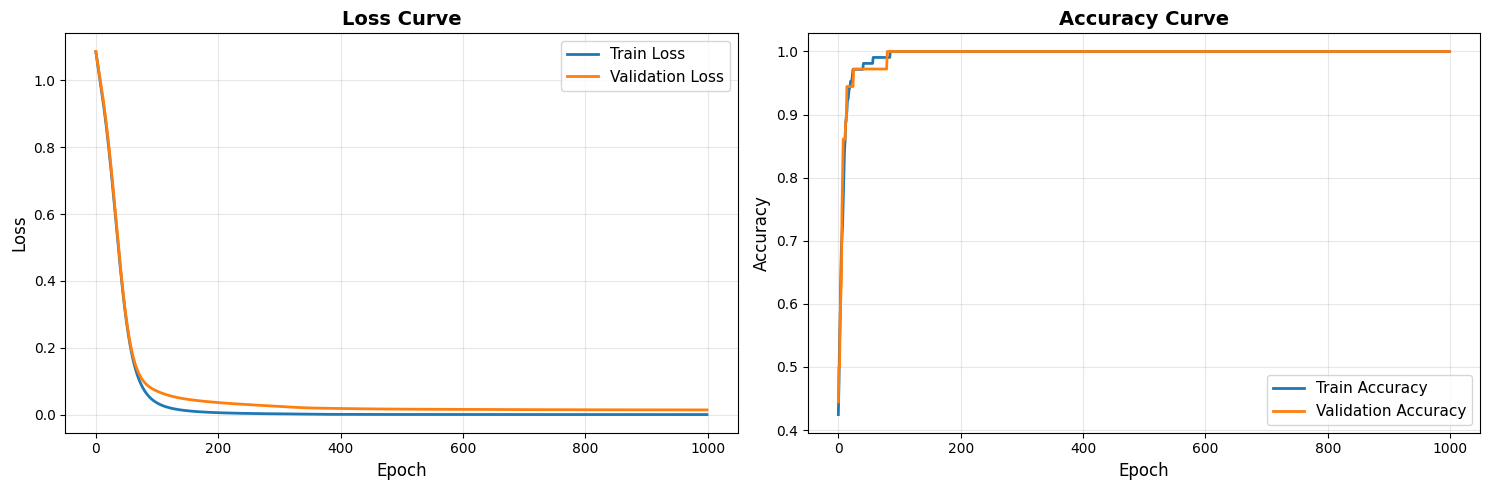


최종 학습 결과
훈련 손실: 0.0001
검증 손실: 0.0140
훈련 정확도: 1.0000 (100.00%)
검증 정확도: 1.0000 (100.00%)


In [120]:
def plot_training_history(history):


    fig, axes = plt.subplots(1, 2, figsize=(15, 5))


    # 손실(Loss) 그래프
    axes[0].plot(history['train_losses'], label='Train Loss', linewidth=2)
    axes[0].plot(history['val_losses'], label='Validation Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Loss Curve', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)


    # 정확도(Accuracy) 그래프
    axes[1].plot(history['train_accs'], label='Train Accuracy', linewidth=2)
    axes[1].plot(history['val_accs'], label='Validation Accuracy', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title('Accuracy Curve', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)


    plt.tight_layout()
    plt.show()


    # 최종 결과 출력
    print("\n" + "=" * 50)
    print("최종 학습 결과")
    print("=" * 50)
    print(f"훈련 손실: {history['train_losses'][-1]:.4f}")
    print(f"검증 손실: {history['val_losses'][-1]:.4f}")
    print(f"훈련 정확도: {history['train_accs'][-1]:.4f} ({history['train_accs'][-1]*100:.2f}%)")
    print(f"검증 정확도: {history['val_accs'][-1]:.4f} ({history['val_accs'][-1]*100:.2f}%)")
    print("=" * 50)


# 학습 과정 시각화
plot_training_history(history)

In [125]:
def test_model(model, inputs_test, labels_test):
    test_loss, test_acc = evaluate_model(model, inputs_test, labels_test)

    print(f'테스트 손실: {test_loss:.4f}')
    print(f'테스트 정확도: {test_acc:.4f} ({test_acc*100:.2f}%)')

    # 클래스별 예측 결과
    model.eval()
    with torch.no_grad():
        outputs = model(inputs_test)
        # Fix: Correctly unpack the result of torch.max
        _, predicted = torch.max(outputs, 1)

    # 클래스별 정확도 계산
    for class_idx in range(3):
        # Fix: class_mask should be a boolean tensor, not a set
        class_mask = (labels_test == class_idx)
        # Fix: predicted and labels_test should be indexed directly with the boolean mask
        class_correct = (predicted[class_mask] == labels_test[class_mask]).sum().item()
        class_total = class_mask.sum().item()
        class_accuracy = class_correct / class_total if class_total > 0 else 0
        print(f'클래스:{class_idx}, 정확도:{class_accuracy:.4f}')

In [126]:
test_model(model, inputs_test, labels_test)

테스트 손실: 0.1854
테스트 정확도: 0.9444 (94.44%)
클래스:0, 정확도:0.9167
클래스:1, 정확도:1.0000
클래스:2, 정확도:0.9000
